# `mvkit`: a guided tour

`mvkit` is a small Rust + Python library for simulating McKean-Vlasov SDEs and solving Mean Field Games. The Rust core handles the inner loop (parallel particle update, deterministic noise sampling) and Python wraps it with an ergonomic API plus pure-Python utilities for propagation-of-chaos rate estimation and MFG solvers.

This notebook is the single best entry point to the library. It walks through the four built-in models, the two meta-tools (propagation of chaos, LQ-MFG), and ends with a small applied vignette on a basket of correlated CIR variance processes.

Audience: quantitative researchers and applied probabilists comfortable with basic stochastic calculus. Reading time: about 30 to 45 minutes.

## Setup

A single seed convention: every simulation in this notebook is reproducible. Pass `seed=...` to any `simulate_*` function and identical inputs give bit-exact identical outputs, regardless of thread count.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import mvkit
from mvkit import (
    simulate_cucker_smale,
    simulate_kuramoto,
    simulate_linear_quadratic,
    simulate_mean_field_cir,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110})

print(f"mvkit {mvkit.__version__}, numpy {np.__version__}")

mvkit 0.1.0, numpy 2.4.4


## 1. The linear-quadratic McKean-Vlasov model

The simplest non-trivial mean-field SDE: scalar state, linear drift coupling self and population mean, additive noise.

$$
\mathrm{d}X_t = (a\, X_t + b\, \bar X_t)\, \mathrm{d}t + \sigma\, \mathrm{d}W_t,
\qquad X_0 \sim \mathcal{N}(m_0, v_0).
$$

Because the drift is linear and the noise is additive, the marginal law stays Gaussian for all $t$, with closed-form moments:

$$
m(t) = m_0 \exp\big((a + b)\, t\big), \qquad
v(t) = v_0 \exp(2 a t) + \sigma^2 \frac{\exp(2 a t) - 1}{2 a}.
$$

These exact moments make LQ the canonical correctness benchmark for any mean-field integrator.

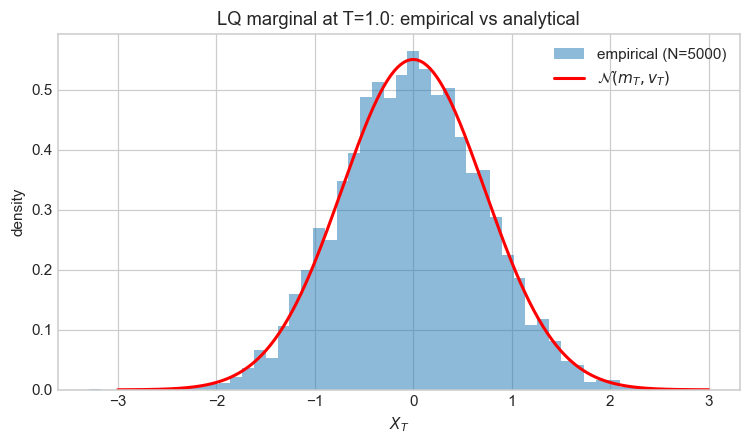

analytical m_T = 0.0000, v_T = 0.5259
empirical m_T = -0.0094, v_T = 0.5219


In [2]:
n, T, n_steps = 5000, 1.0, 2000
a, b, sigma = -0.5, 1.0, 0.5
m_0, v_0 = 0.0, 1.0

rng = np.random.default_rng(0)
x0 = rng.normal(m_0, np.sqrt(v_0), size=(n, 1))
hist = simulate_linear_quadratic(
    x0, t_final=T, n_steps=n_steps, a=a, b=b, sigma=sigma, seed=0
)

m_T = m_0 * np.exp((a + b) * T)
v_T = v_0 * np.exp(2 * a * T) + sigma**2 * (np.exp(2 * a * T) - 1) / (2 * a)

xs = np.linspace(-3.0, 3.0, 400)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(hist[-1, :, 0], bins=50, density=True, alpha=0.5,
        color="tab:blue", label=f"empirical (N={n})")
ax.plot(xs, norm(loc=m_T, scale=np.sqrt(v_T)).pdf(xs),
        "r-", lw=2, label=rf"$\mathcal{{N}}(m_T, v_T)$")
ax.set_xlabel(r"$X_T$")
ax.set_ylabel("density")
ax.set_title(f"LQ marginal at T={T}: empirical vs analytical")
ax.legend()
plt.show()

print(f"analytical m_T = {m_T:.4f}, v_T = {v_T:.4f}")
print(f"empirical m_T = {hist[-1, :, 0].mean():.4f}, "
      f"v_T = {hist[-1, :, 0].var():.4f}")

The empirical histogram tracks the analytical Gaussian density to within Monte Carlo noise. With `a + b = 0.5 > 0` the mean drifts to the right; with `a < 0` the variance stabilizes around `sigma^2 / (-2a) = 0.25` rather than blowing up.

## 2. Cucker-Smale flocking

A model of self-organizing collective motion: particles in $\mathbb{R}^d$ with positions $x_i$ and velocities $v_i$, aligning their velocities through a long-range kernel:

$$
\mathrm{d}x_i = v_i\, \mathrm{d}t,
\qquad
\mathrm{d}v_i = \frac{1}{N}\sum_{j=1}^N K(\lvert x_j - x_i \rvert)\,(v_j - v_i)\, \mathrm{d}t + \sigma\, \mathrm{d}W_i,
$$

with kernel $K(r) = (1 + r^2)^{-\beta}$. The deterministic part conserves the mean velocity $\bar v = \tfrac{1}{N}\sum v_i$, which is the textbook sanity check on any integrator. For $\beta < 1/2$, velocities concentrate around $\bar v$ unconditionally (Cucker and Smale 2007).

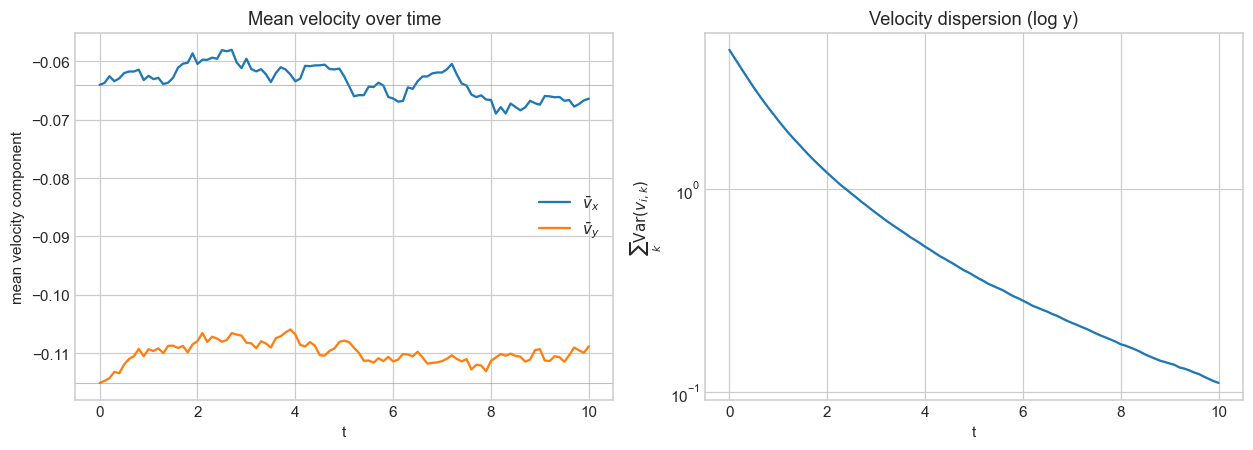

max drift in mean velocity over the run: 0.0092
residual MC fluctuation expected (sigma sqrt(T/N) ~ 0.0091)


In [3]:
rng = np.random.default_rng(1)
n_cs, d = 300, 2
x0_cs = np.empty((n_cs, 2 * d))
x0_cs[:, :d] = rng.normal(scale=2.0, size=(n_cs, d))
x0_cs[:, d:] = rng.normal(scale=1.5, size=(n_cs, d))

history = simulate_cucker_smale(
    x0_cs, t_final=10.0, n_steps=2000, spatial_dim=d,
    beta=0.4, sigma=0.05, record_every=20, seed=1,
)
times = np.linspace(0.0, 10.0, history.shape[0])

vel = history[..., d:]
mean_vel = vel.mean(axis=1)
vel_disp = vel.var(axis=1).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(times, mean_vel[:, 0], label=r"$\bar v_x$")
axes[0].plot(times, mean_vel[:, 1], label=r"$\bar v_y$")
axes[0].axhline(mean_vel[0, 0], color="grey", lw=0.7, alpha=0.5)
axes[0].axhline(mean_vel[0, 1], color="grey", lw=0.7, alpha=0.5)
axes[0].set_xlabel("t")
axes[0].set_ylabel("mean velocity component")
axes[0].set_title("Mean velocity over time")
axes[0].legend()
axes[1].semilogy(times, vel_disp, color="tab:blue")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\sum_k \mathrm{Var}(v_{i,k})$")
axes[1].set_title("Velocity dispersion (log y)")
plt.tight_layout()
plt.show()

drift = float(np.max(np.abs(mean_vel - mean_vel[0])))
print(f"max drift in mean velocity over the run: {drift:.4f}")
print(f"residual MC fluctuation expected (sigma sqrt(T/N) ~ {0.05 * np.sqrt(10/n_cs):.4f})")

Left panel: the mean velocity stays flat (the small wiggle is from the diffusion, of order $\sigma \sqrt{T/N}$). Right panel: the velocity dispersion decays exponentially, classic flocking behaviour with $\beta < 1/2$.

## 3. Kuramoto and the synchronization transition

Phase oscillators on the circle, with heterogeneous natural frequencies $\omega_i$ and all-to-all coupling:

$$
\mathrm{d}\theta_i = \omega_i\, \mathrm{d}t
+ \frac{K}{N}\sum_{j=1}^N \sin(\theta_j - \theta_i)\, \mathrm{d}t + \sigma\, \mathrm{d}W_i.
$$

Synchronization is captured by the order parameter $r(t) = \big| \tfrac{1}{N} \sum_j e^{i\theta_j(t)} \big|$. For Gaussian $\omega_i \sim \mathcal{N}(0, \sigma_\omega^2)$ the critical coupling is

$$
K_c = 2\, \sigma_\omega \sqrt{2/\pi}.
$$

Below $K_c$ the population stays incoherent ($r \to 0$ as $N \to \infty$); above $K_c$ a fraction of oscillators lock and $r$ stabilizes between 0 and 1.

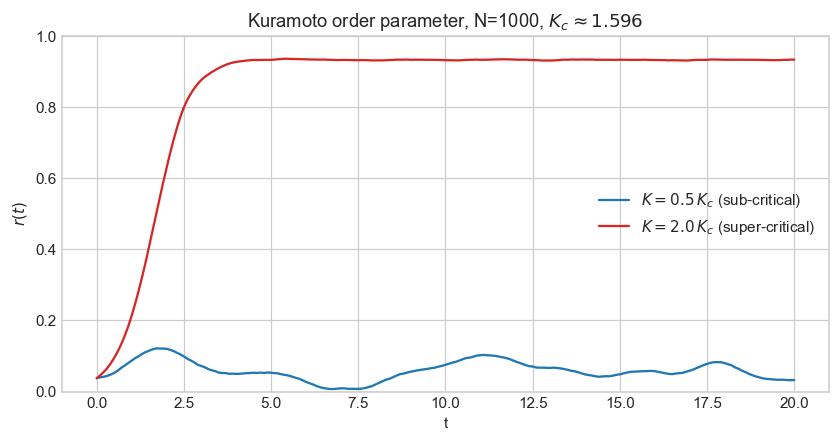

In [4]:
rng = np.random.default_rng(2)
n_kur = 1000
sigma_omega = 1.0
omegas = rng.normal(scale=sigma_omega, size=n_kur)
K_c = 2.0 * sigma_omega * np.sqrt(2.0 / np.pi)

x0_kur = rng.uniform(-np.pi, np.pi, size=(n_kur, 1))


def order_parameter(theta_history):
    return np.abs(np.exp(1j * theta_history[..., 0]).mean(axis=1))


hist_sub = simulate_kuramoto(
    x0_kur, t_final=20.0, n_steps=4000, coupling_k=0.5 * K_c,
    omegas=omegas, sigma=0.1, record_every=20, seed=2,
)
hist_sup = simulate_kuramoto(
    x0_kur, t_final=20.0, n_steps=4000, coupling_k=2.0 * K_c,
    omegas=omegas, sigma=0.1, record_every=20, seed=3,
)
times_k = np.linspace(0.0, 20.0, hist_sub.shape[0])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(times_k, order_parameter(hist_sub), color="tab:blue",
        label=rf"$K = 0.5\, K_c$ (sub-critical)")
ax.plot(times_k, order_parameter(hist_sup), color="tab:red",
        label=rf"$K = 2.0\, K_c$ (super-critical)")
ax.set_xlabel("t")
ax.set_ylabel(r"$r(t)$")
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Kuramoto order parameter, N={n_kur}, "
             rf"$K_c \approx {K_c:.3f}$")
ax.legend()
plt.show()

Sub-critical ($K = 0.5 K_c$): $r(t)$ stays low, the population is incoherent. Super-critical ($K = 2 K_c$): $r(t)$ rises and stabilizes around the mean-field prediction. This is the cleanest live demo of a phase transition in a mean-field SDE.

## 4. Mean-field Cox-Ingersoll-Ross

A mean-reverting square-root process with a McKean-Vlasov interaction term:

$$
\mathrm{d}X_i = \kappa\, (\theta - X_i)\, \mathrm{d}t
+ b\, (\bar X - X_i)\, \mathrm{d}t
+ \sigma\, \sqrt{\max(X_i, 0)}\, \mathrm{d}W_i.
$$

The first drift term is the standard CIR pull toward the long-run mean $\theta$ at rate $\kappa$; the second is the McKean-Vlasov pull toward the empirical mean. The Feller condition $2\kappa\theta \ge \sigma^2$ keeps the continuous-time process strictly positive. The diffusion is state-dependent, which is why this model exercises the Milstein integrator's correction term in a non-trivial way.

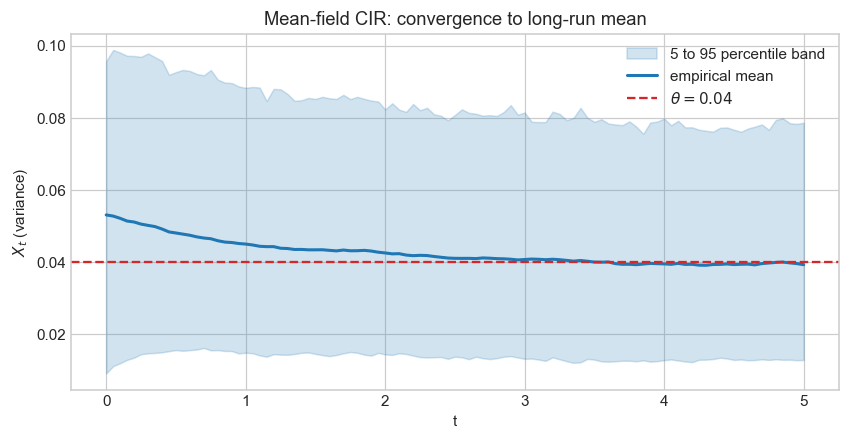

In [5]:
rng = np.random.default_rng(4)
n_cir = 2000
kappa, theta_, b_, sigma_cir = 1.0, 0.04, 0.5, 0.18
# Feller: 2 kappa theta = 0.08, sigma^2 = 0.0324, so OK.

x0_cir = rng.uniform(0.005, 0.10, size=(n_cir, 1))

hist_cir = simulate_mean_field_cir(
    x0_cir, t_final=5.0, n_steps=2000,
    kappa=kappa, theta=theta_, b=b_, sigma=sigma_cir,
    record_every=20, seed=4, scheme="milstein",
)
times_cir = np.linspace(0.0, 5.0, hist_cir.shape[0])

mean_t = hist_cir[..., 0].mean(axis=1)
q05 = np.quantile(hist_cir[..., 0], 0.05, axis=1)
q95 = np.quantile(hist_cir[..., 0], 0.95, axis=1)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.fill_between(times_cir, q05, q95, color="tab:blue", alpha=0.2,
                label="5 to 95 percentile band")
ax.plot(times_cir, mean_t, color="tab:blue", lw=2, label="empirical mean")
ax.axhline(theta_, color="tab:red", linestyle="--", lw=1.5,
           label=rf"$\theta = {theta_}$")
ax.set_xlabel("t")
ax.set_ylabel(r"$X_t$ (variance)")
ax.set_title("Mean-field CIR: convergence to long-run mean")
ax.legend()
plt.show()

The empirical mean approaches $\theta$ exponentially fast at rate roughly $\kappa + b$, faster than a non-interacting CIR which would converge at $\kappa$ alone. The percentile band tightens as the population concentrates around $\theta$.

## 5. Propagation of chaos, quantitatively

For a McKean-Vlasov SDE with i.i.d. initial conditions, Sznitman (1991) shows that the empirical measure $\mu_N$ of the $N$-particle system converges to the McKean-Vlasov limit $\mu$ as $N \to \infty$. Fournier and Guillin (2015) sharpened this to a quantitative rate: in dimension 1, for laws with a finite $(4 + \varepsilon)$-th moment,
$$
\mathbb{E}\big[W_2(\mu_N, \mu)\big] = O(N^{-1/2}).
$$

We can recover that $-1/2$ slope numerically with `mvkit.poc`. Take the LQ model, compute the analytical $\mathcal{N}(m_T, v_T)$ reference, sweep $N$, and fit the log-log slope.

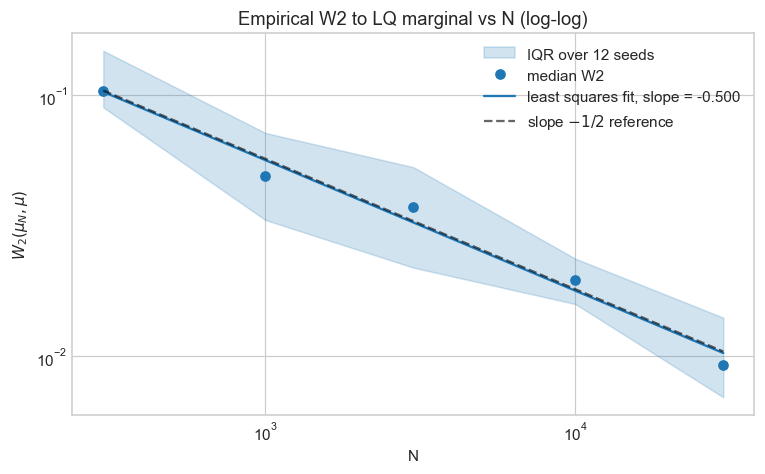

fitted slope = -0.5005, target = -0.5


In [6]:
from mvkit.poc import estimate_propagation_of_chaos_rate

a, b, sigma_lq, T_lq = -0.5, 1.0, 0.5, 1.0
m_0_lq, v_0_lq = 0.0, 1.0
m_T_ref = m_0_lq * np.exp((a + b) * T_lq)
v_T_ref = v_0_lq * np.exp(2 * a * T_lq) + sigma_lq**2 * (
    np.exp(2 * a * T_lq) - 1
) / (2 * a)
ref_law = norm(loc=m_T_ref, scale=np.sqrt(v_T_ref))


def lq_simulator(n, seed):
    rng = np.random.default_rng(seed)
    x0_local = rng.normal(m_0_lq, np.sqrt(v_0_lq), size=(n, 1))
    h = simulate_linear_quadratic(
        x0_local, T_lq, 1000, a=a, b=b, sigma=sigma_lq, seed=seed
    )
    return h[-1, :, 0]


result = estimate_propagation_of_chaos_rate(
    simulator=lq_simulator,
    reference_inv_cdf=ref_law.ppf,
    n_values=[300, 1000, 3000, 10000, 30000],
    n_seeds=16,
)

n_arr = result.n_values.astype(float)
fit = np.exp(result.fitted_intercept) * n_arr ** result.fitted_slope
ref_line = result.w2_median[0] * (n_arr / n_arr[0]) ** -0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(n_arr, result.w2_q25, result.w2_q75,
                alpha=0.2, color="tab:blue", label="IQR over 12 seeds")
ax.loglog(n_arr, result.w2_median, "o", color="tab:blue", label="median W2")
ax.loglog(n_arr, fit, "-", color="tab:blue",
          label=f"least squares fit, slope = {result.fitted_slope:.3f}")
ax.loglog(n_arr, ref_line, "k--", alpha=0.6, label=r"slope $-1/2$ reference")
ax.set_xlabel("N")
ax.set_ylabel(r"$W_2(\mu_N, \mu)$")
ax.set_title("Empirical W2 to LQ marginal vs N (log-log)")
ax.legend()
plt.show()

print(f"fitted slope = {result.fitted_slope:.4f}, target = -0.5")

The fitted slope sits on top of the $-1/2$ reference, validating Fournier-Guillin's rate on this model. A pleasant numerical confirmation of a deep theoretical result.

## 6. Solving an LQ Mean Field Game

The LQ-MFG asks for an equilibrium mean trajectory $m_t$ such that, when each agent best-responds to that mean, the resulting population mean reproduces $m_t$. With the cost
$$
J(\alpha; m) = \mathbb{E}\!\left[ \int_0^T \tfrac{1}{2}(\alpha_t^2 + q (X_t - m_t)^2)\, \mathrm{d}t + \tfrac{1}{2} q_T (X_T - m_T)^2 \right],
$$
the HJB ansatz $u(t, x) = \tfrac{1}{2} P(t) x^2 + Q(t) x + R(t)$ reduces the problem to a Riccati ODE for $P(t)$ (independent of $m$) plus a linear ODE for $Q(t)$ that couples to $m$. In the symmetric case, the equilibrium mean is constant $m_t = m_0$ and the variance $V(t)$ solves $\dot V = -2 P V + \sigma^2$.

Two iterative solvers are available: Picard (geometric where contracting) and Fictitious Play (Cardaliaguet and Hadikhanloo, 2017; $O(1/k)$ rate but does not require contraction).

Picard: converged=True, n_iter=6
FP:     converged=True, n_iter=24


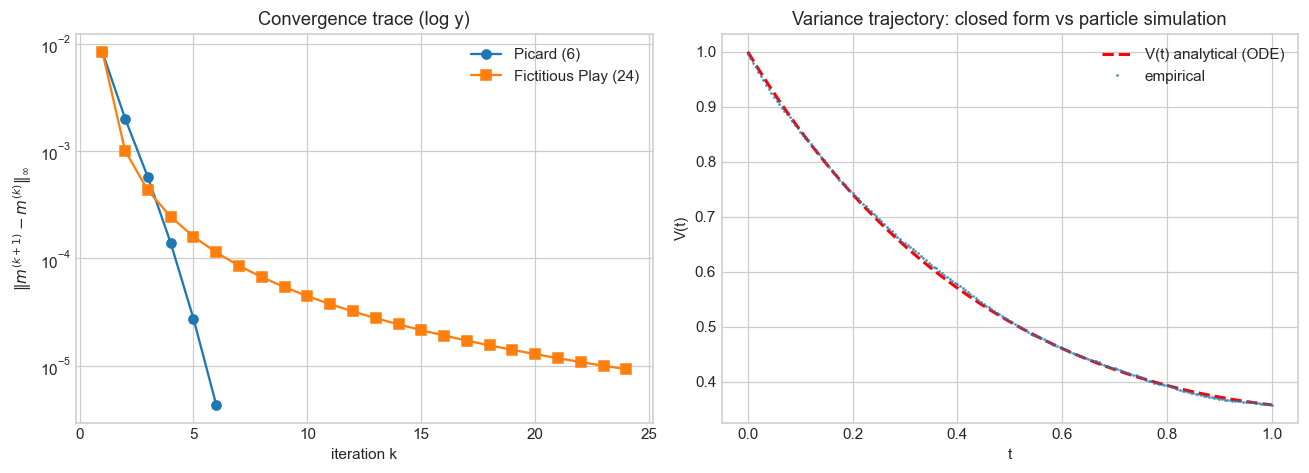

In [7]:
from mvkit.mfg import solve_lq_mfg, solve_lq_mfg_fictitious_play

q, q_T, sigma_mfg, T_mfg = 1.0, 0.5, 0.5, 1.0
mu_0_mean, mu_0_var = 0.5, 1.0

sol_p = solve_lq_mfg(
    q=q, q_T=q_T, sigma=sigma_mfg, T=T_mfg,
    mu_0_mean=mu_0_mean, mu_0_var=mu_0_var,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
    n_iterations_max=30,
)
sol_fp = solve_lq_mfg_fictitious_play(
    q=q, q_T=q_T, sigma=sigma_mfg, T=T_mfg,
    mu_0_mean=mu_0_mean, mu_0_var=mu_0_var,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
    n_iterations_max=120,
)

print(f"Picard: converged={sol_p.converged}, n_iter={sol_p.n_iterations}")
print(f"FP:     converged={sol_fp.converged}, n_iter={sol_fp.n_iterations}")


def increments(it):
    return [float(np.max(np.abs(it[k + 1] - it[k]))) for k in range(len(it) - 1)]


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.semilogy(np.arange(1, sol_p.n_iterations + 1), increments(sol_p.m_iterates),
            "o-", color="tab:blue", label=f"Picard ({sol_p.n_iterations})")
ax.semilogy(np.arange(1, sol_fp.n_iterations + 1), increments(sol_fp.m_iterates),
            "s-", color="tab:orange", label=f"Fictitious Play ({sol_fp.n_iterations})")
ax.set_xlabel("iteration k")
ax.set_ylabel(r"$\|m^{(k+1)} - m^{(k)}\|_\infty$")
ax.set_title("Convergence trace (log y)")
ax.legend()

ax = axes[1]
emp_var = sol_p.x_trajectory.var(axis=1)
ax.plot(sol_p.t_grid, sol_p.V, "r--", lw=2, label="V(t) analytical (ODE)")
ax.plot(sol_p.t_grid, emp_var, ".", color="tab:blue", markersize=2,
        alpha=0.6, label="empirical")
ax.set_xlabel("t")
ax.set_ylabel("V(t)")
ax.set_title("Variance trajectory: closed form vs particle simulation")
ax.legend()
plt.tight_layout()
plt.show()

Left: Picard hits the tolerance in roughly ten iterations with clean geometric decay; Fictitious Play converges on the same equilibrium but at the slower polynomial rate predicted by the theory. Right: the analytical variance ODE matches the empirical particle variance over the entire horizon, validating the solver against ground truth.

## 7. Applied vignette: a CIR vol basket under stress

A small illustrative case study: take $N$ assets whose instantaneous variances follow correlated mean-field CIR dynamics. We initialize one asset at $V_0 = 0.16$ (a stressed asset, vol $= 40\%$), the rest at $V_0 = 0.04$ (vol $= 20\%$), and use a positive mean-field coupling $b > 0$. We then watch how the basket absorbs the shock.

This is illustrative only, not a serious financial model. It is meant to show what the API looks like once you start composing the building blocks.

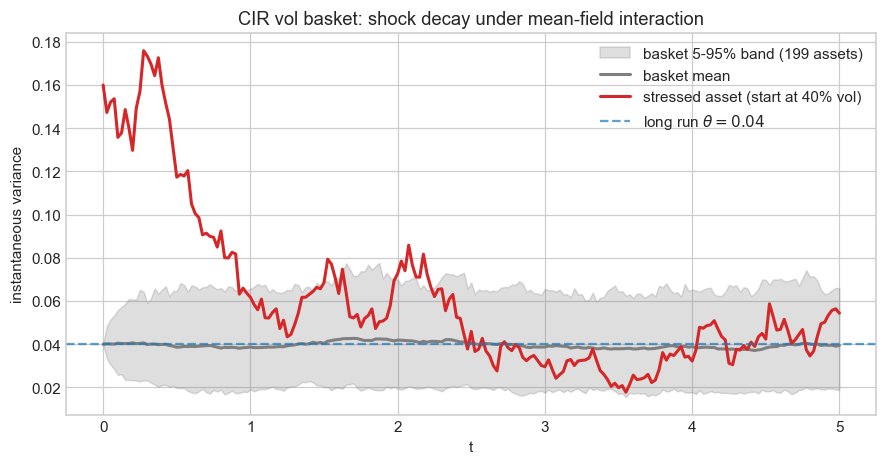

stressed asset variance at t=0: 0.1600 (vol = 40%)
stressed asset variance at t=T: 0.0544 (vol = 23.3%)
basket mean at t=0: 0.0400, at t=T: 0.0394


In [8]:
n_basket = 200
kappa_b, theta_b, b_b, sigma_b = 1.5, 0.04, 0.5, 0.15
# Feller: 2 kappa theta = 0.12, sigma^2 = 0.0225, OK.

x0_basket = np.full(n_basket, 0.04)
x0_basket[0] = 0.16  # stressed asset, 40% vol initial
x0_basket = x0_basket.reshape(-1, 1)

hist_b = simulate_mean_field_cir(
    x0_basket, t_final=5.0, n_steps=2000,
    kappa=kappa_b, theta=theta_b, b=b_b, sigma=sigma_b,
    record_every=10, seed=42, scheme="milstein",
)
times_b = np.linspace(0.0, 5.0, hist_b.shape[0])

stressed = hist_b[:, 0, 0]
basket_others = hist_b[:, 1:, 0]
basket_mean = basket_others.mean(axis=1)
basket_q05 = np.quantile(basket_others, 0.05, axis=1)
basket_q95 = np.quantile(basket_others, 0.95, axis=1)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(times_b, basket_q05, basket_q95, color="tab:gray",
                alpha=0.25, label="basket 5-95% band (199 assets)")
ax.plot(times_b, basket_mean, color="tab:gray", lw=2, label="basket mean")
ax.plot(times_b, stressed, color="tab:red", lw=2,
        label="stressed asset (start at 40% vol)")
ax.axhline(theta_b, color="tab:blue", linestyle="--", alpha=0.7,
           label=rf"long run $\theta = {theta_b}$")
ax.set_xlabel("t")
ax.set_ylabel("instantaneous variance")
ax.set_title("CIR vol basket: shock decay under mean-field interaction")
ax.legend(loc="upper right")
plt.show()

print(f"stressed asset variance at t=0: {stressed[0]:.4f} (vol = 40%)")
print(f"stressed asset variance at t=T: {stressed[-1]:.4f} "
      f"(vol = {100 * np.sqrt(max(stressed[-1], 0)):.1f}%)")
print(f"basket mean at t=0: {basket_mean[0]:.4f}, at t=T: {basket_mean[-1]:.4f}")

The stressed asset's variance reverts toward $\theta$ on a timescale of order $1/(\kappa + b)$. With 199 calm assets and only one stressed, the basket mean barely registers the shock, just a small bump within the noise band. The mean-field interaction term $b(\bar X - X_i)$ does pull on every asset, but with a single outlier the empirical mean is dominated by the calm crowd, so the shock stays localized. A different realization with a larger fraction of stressed assets (say 30 out of 200) would push the basket mean visibly upward before all assets revert together.

## 8. What `mvkit` is, what it isn't, what's next

What it is. A small, fast, reproducible toolbox for simulating mean-field SDEs in research code. The Rust core is designed for the case where you want to sweep millions of particle-steps per second and still get bit-exact results across runs. The Python API is thin and pedagogically clean: every model has a closed-form benchmark in the test suite, and the propagation-of-chaos and MFG utilities were added in part because they turn the library into a tool you can do quantitative work with rather than just demos. The four built-in models cover the classical canon (LQ, Cucker-Smale, Kuramoto, mean-field CIR) and were chosen because each highlights a different aspect of the mean-field machinery: linear-Gaussian closed form, mean-velocity conservation, phase transition, and state-dependent diffusion.

What it isn't, yet. There is no HJB grid solver, so the MFG sub-module only handles the LQ case in scalar dimension. There is no shared-Brownian-increment hook, which means strong-error tests (pathwise distance between coarse and fine discretizations on the same Brownian path) are not yet possible without going outside the library. The state space is scalar in the MFG sub-module and the LQ-MFG is solved in the symmetric case only. There are no tamed integrators for super-linear drift, so models outside the locally-Lipschitz regime are out of reach. The performance focus is single-machine; there is no GPU back-end and no distributed driver.

What's next. The most useful additions in roughly this order: a Brownian-increment hook on the integrator (small change, unlocks all strong-error work), a vector LQ-MFG with matrix Riccati (small extension of the existing scalar code), a generic HJB grid solver for non-LQ MFG (the big one, semi-Lagrangian or upwind FD), and tamed schemes for super-linear drift. The library is small enough that these are realistic targets for someone working on it part-time.

## Reproducibility

To rerun this notebook from scratch:

```bash
git clone https://github.com/TriGo06/MVKit
cd MVKit
pip install maturin matplotlib scipy ipykernel
maturin develop --release
jupyter notebook notebooks/mvkit_tour.ipynb
```

The cell below prints the exact versions used to produce the figures above. All seeds are baked into the cells, so the figures are bit-exact reproducible.

In [9]:
import sys
import platform
import numpy as np
import scipy
import matplotlib

print(f"python {platform.python_version()}")
print(f"platform {platform.platform()}")
print(f"mvkit {mvkit.__version__}")
print(f"numpy {np.__version__}")
print(f"scipy {scipy.__version__}")
print(f"matplotlib {matplotlib.__version__}")

python 3.12.13
platform macOS-26.3.1-arm64-arm-64bit
mvkit 0.1.0
numpy 2.4.4
scipy 1.17.1
matplotlib 3.10.9
